# Na-22 BaF2-PMT test

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from datetime import datetime

## Functions defined here

In [9]:
def load_data(file_list, channel_list, volt):
    df_ch = {}
    dt = 0
    for ch in channel_list:
        df_ch[ch] = []
        for f in file_list:
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            df_ch[ch].append(df)
            if ch==-1:
                dt = datetime(*np.array(df['start_datetime'][:6]).astype(int))
            df = None
        df_ch[ch] = pd.concat(df_ch[ch]).sort_index()
        if ch!=-1:
            df_ch[ch].rename(columns=lambda x: x+f'_{ch}',inplace=True)            
    df_ch = pd.concat(list(df_ch.values()),axis=1)
    return df_ch, dt

def get_bsl_filt(df_data,channels,rms_thre_ch):
    df_bsl_filt = {}
    for ch in channels:
        df_bsl_filt[f'bsl_filt_{ch}'] = df_data[f'baseline_rms_{ch}']<rms_thre_ch[ch]
        # print(df_bsl_filt[f'bsl_filt_{ch}'].sum())
    df_bsl_filt = pd.DataFrame(df_bsl_filt)
    df_bsl_filt['bsl_filt'] =  df_bsl_filt[[f'bsl_filt_{ch}' for ch in channels]].all(axis=1)
    return df_bsl_filt

def get_bsl_rms_hist(df_data,channels,bins,range):
    hist_ch = {}
    for ch in channels:
        hist_ch[ch] = np.histogram(df_data[f'baseline_rms_{ch}'], bins=bins, range=range)
    return hist_ch

def get_bsl_mean_hist(df_data,channels,bsl_filt,bins,range):
    hist_ch = {}
    for ch in channels:
        if bsl_filt:
            hist_ch[ch] = np.histogram(df_data.loc[df_data[f'bsl_filt_{ch}'],f'baseline_mean_{ch}'], bins=bins, range=range)
        else:
            hist_ch[ch] = np.histogram(df_data[f'baseline_mean_{ch}'], bins=bins, range=range)
    return hist_ch

## Organize file paths

In [3]:
path = "/scratch/gpfs/as111/results/"
degrees = [90, 180]
files = [glob(f'{path}*/*light_baf2*cond_{deg}deg*liq8.h5') for deg in degrees]
for f in files:
    print(len(f), f)

5 ['/scratch/gpfs/as111/results/2025-02-05/2025-02-05_volt_2500_light_baf2_cond_90deg_source_na22_xenon_0_run3_baf2_liq8.h5', '/scratch/gpfs/as111/results/2025-02-05/2025-02-05_volt_2500_light_baf2_cond_90deg_source_na22_xenon_0_run0_baf2_liq8.h5', '/scratch/gpfs/as111/results/2025-02-05/2025-02-05_volt_2500_light_baf2_cond_90deg_source_na22_xenon_0_run2_baf2_liq8.h5', '/scratch/gpfs/as111/results/2025-02-05/2025-02-05_volt_2500_light_baf2_cond_90deg_source_na22_xenon_0_run4_baf2_liq8.h5', '/scratch/gpfs/as111/results/2025-02-05/2025-02-05_volt_2500_light_baf2_cond_90deg_source_na22_xenon_0_run1_baf2_liq8.h5']
5 ['/scratch/gpfs/as111/results/2025-02-05/2025-02-05_volt_2500_light_baf2_cond_180deg_source_na22_xenon_0_run0_baf2_liq8.h5', '/scratch/gpfs/as111/results/2025-02-05/2025-02-05_volt_2500_light_baf2_cond_180deg_source_na22_xenon_0_run3_baf2_liq8.h5', '/scratch/gpfs/as111/results/2025-02-05/2025-02-05_volt_2500_light_baf2_cond_180deg_source_na22_xenon_0_run1_baf2_liq8.h5', '/scrat

## Read data

In [5]:
data = {}
channels = [0, 3]
volt = 2500
date_time = []
for i, deg in enumerate(degrees):
    data[deg], dt = load_data(files[i], channels, volt)
    print(f'{deg}deg: {data[deg].shape[0]} events {dt}')
    date_time.append(dt)
print('columns: ', list(data[degrees[0]].columns))

90deg: 250075 events 0
180deg: 250955 events 0
columns:  ['baseline_mean_0', 'baseline_rms_0', 'integral_0', 'amplitude_0', 'peakpos_0', 'baseline_mean_3', 'baseline_rms_3', 'integral_3', 'amplitude_3', 'peakpos_3']


## Pre-trigger RMS cut

In [10]:
rms_threshold = {0: 2.0, 3: 2.0}
for deg in degrees:
    df_bsl_filt = get_bsl_filt(data[deg],[0,3],rms_threshold)
    data[deg][df_bsl_filt.columns] = df_bsl_filt
    df_bsl_filt = None

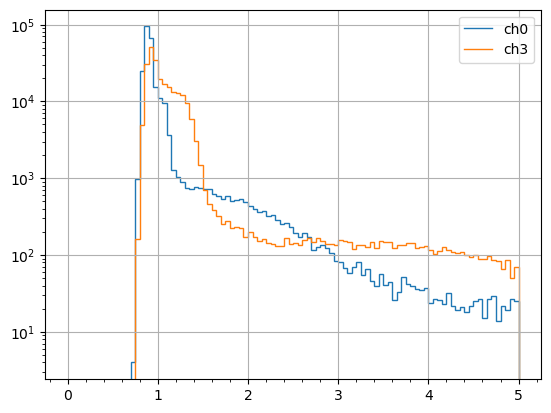

In [20]:
deg = 90
hists = get_bsl_rms_hist(data[deg],[0, 3],100,(0,5))
for ch,hist in hists.items():
	plt.stairs(*(hist),label=f'ch{ch}')
plt.legend()
plt.yscale('log')
plt.grid()
plt.minorticks_on()

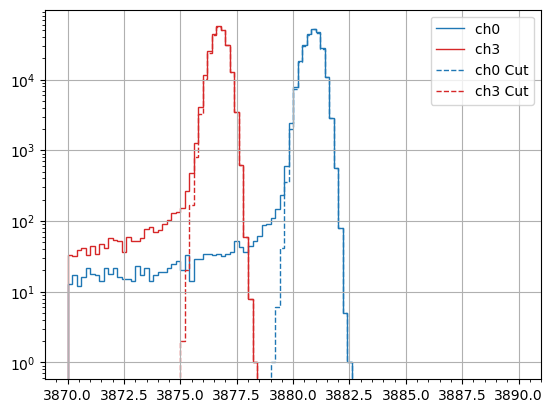

In [19]:
deg = 90
hists_nc = get_bsl_mean_hist(data[deg],[0, 3],False,100,(3870,3890))
hists_ac = get_bsl_mean_hist(data[deg],[0, 3],True,100,(3870,3890))
for ch,hist in hists_nc.items():
	plt.stairs(*(hist),color=f'C{ch}',label=f'ch{ch} ')
for ch,hist in hists_ac.items():
	plt.stairs(*(hist),color=f'C{ch}',label=f'ch{ch} Cut',ls='--')
plt.legend()
plt.yscale('log')
plt.grid()
plt.minorticks_on()

# 2D Spectra (Integral)

In [27]:
nbinsx = 500
range_minx = 0
range_maxx = 1e5
nbinsy = 500
range_miny = 0
range_maxy = 1e5

d1_d2_itg = {}
for deg in degrees:
    d1_d2_itg[deg] = {}
    bsl_filt = data[deg]['bsl_filt']
    d1_d2_itg[deg]['counts'], d1_d2_itg[deg]['xbins'], d1_d2_itg[deg]['ybins'] = np.histogram2d(
        data[deg]['integral_0'][bsl_filt], 
        data[deg]['integral_3'][bsl_filt], 
        bins=[nbinsx,nbinsy], range=[[range_minx,range_maxx],[range_miny,range_maxy]]
    )
    d1_d2_itg[deg]['counts'] = d1_d2_itg[deg]['counts'].T
    d1_d2_itg[deg]['xbins'], d1_d2_itg[deg]['ybins'] = np.meshgrid(
        d1_d2_itg[deg]['xbins'], d1_d2_itg[deg]['ybins']
    )

/tmp/ipykernel_3096443/2322395453.py:9: RuntimeWarning: divide by zero encountered in log10
  np.log10(d1_d2_itg[deg]['counts'])


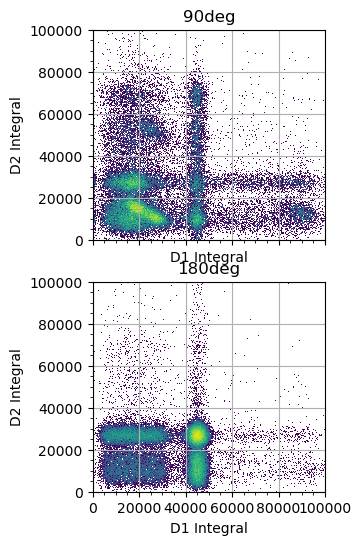

In [28]:
nrows = 2
fig, axs = plt.subplots(nrows, 1, sharex=True, sharey=True)
fig.set_size_inches(3, 3*nrows)

for i, deg in enumerate(degrees):
    axs[i].pcolormesh(
        d1_d2_itg[deg]['xbins'],
        d1_d2_itg[deg]['ybins'],
        np.log10(d1_d2_itg[deg]['counts'])
    )
    axs[i].minorticks_on()
    axs[i].grid()
    axs[i].set_title(f'{deg}deg')
    axs[i].set_xlim(0, 1e5)
    axs[i].set_ylim(0, 1e5)
    axs[i].set_xlabel(r'D1 Integral')
    axs[i].set_ylabel(r'D2 Integral')
    
# x1, y1, x2, y2 = 400, 5, 1000, 40
# axs[i].plot([x1,x1], [y1,y2], 'k--', linewidth=0.8)
# axs[i].plot([x2,x2], [y1,y2], 'k--', linewidth=0.8)
# axs[i].plot([x1,x2], [y1,y1], 'k--', linewidth=0.8)
# axs[i].plot([x1,x2], [y2,y2], 'k--', linewidth=0.8)

# mask_x, mask_y = (fs_nofs_pe[c]['xbins'][0,1:]<x2)&(fs_nofs_pe[c]['xbins'][0,1:]>x1), (fs_nofs_pe[c]['ybins'][1:,0]<y2)&(fs_nofs_pe[c]['ybins'][1:,0]>y1)
# bkg_scale = {}
# for c in cond[:-1]:
#     bkg_scale[c] = np.sum(fs_nofs_pe[c]['counts'][mask_y][:,mask_x])/np.sum(fs_nofs_pe['Background']['counts'][mask_y][:,mask_x])
#     print(f'Background to be scaled by {bkg_scale[c]} in {c} data')

## 2D Spectra (Amplitude)

In [29]:
nbinsx = 500
range_minx = 0
range_maxx = 5e3
nbinsy = 500
range_miny = 0
range_maxy = 5e3

d1_d2_amp = {}
for deg in degrees:
    d1_d2_amp[deg] = {}
    bsl_filt = data[deg]['bsl_filt']
    d1_d2_amp[deg]['counts'], d1_d2_amp[deg]['xbins'], d1_d2_amp[deg]['ybins'] = np.histogram2d(
        data[deg]['amplitude_0'][bsl_filt], 
        data[deg]['amplitude_3'][bsl_filt], 
        bins=[nbinsx,nbinsy], range=[[range_minx,range_maxx],[range_miny,range_maxy]]
    )
    d1_d2_amp[deg]['counts'] = d1_d2_amp[deg]['counts'].T
    d1_d2_amp[deg]['xbins'], d1_d2_amp[deg]['ybins'] = np.meshgrid(
        d1_d2_amp[deg]['xbins'], d1_d2_amp[deg]['ybins']
    )

/tmp/ipykernel_3096443/1263157423.py:9: RuntimeWarning: divide by zero encountered in log10
  np.log10(d1_d2_amp[deg]['counts'])


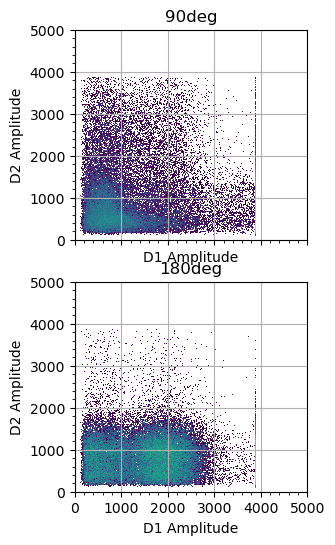

In [30]:
nrows = 2
fig, axs = plt.subplots(nrows, 1, sharex=True, sharey=True)
fig.set_size_inches(3, 3*nrows)

for i, deg in enumerate(degrees):
    axs[i].pcolormesh(
        d1_d2_amp[deg]['xbins'],
        d1_d2_amp[deg]['ybins'],
        np.log10(d1_d2_amp[deg]['counts'])
    )
    axs[i].minorticks_on()
    axs[i].grid()
    axs[i].set_title(f'{deg}deg')
    axs[i].set_xlim(0, 5e3)
    axs[i].set_ylim(0, 5e3)
    axs[i].set_xlabel(r'D1 Amplitude')
    axs[i].set_ylabel(r'D2 Amplitude')
    
# x1, y1, x2, y2 = 400, 5, 1000, 40
# axs[i].plot([x1,x1], [y1,y2], 'k--', linewidth=0.8)
# axs[i].plot([x2,x2], [y1,y2], 'k--', linewidth=0.8)
# axs[i].plot([x1,x2], [y1,y1], 'k--', linewidth=0.8)
# axs[i].plot([x1,x2], [y2,y2], 'k--', linewidth=0.8)

# mask_x, mask_y = (fs_nofs_pe[c]['xbins'][0,1:]<x2)&(fs_nofs_pe[c]['xbins'][0,1:]>x1), (fs_nofs_pe[c]['ybins'][1:,0]<y2)&(fs_nofs_pe[c]['ybins'][1:,0]>y1)
# bkg_scale = {}
# for c in cond[:-1]:
#     bkg_scale[c] = np.sum(fs_nofs_pe[c]['counts'][mask_y][:,mask_x])/np.sum(fs_nofs_pe['Background']['counts'][mask_y][:,mask_x])
#     print(f'Background to be scaled by {bkg_scale[c]} in {c} data')